# Vertebral Column Classification Using Support Vector Machine (SVM)

# Problem Statement

Lower back disorders are among the most common musculoskeletal problems and can significantly affect an individual's quality of life. Early identification of vertebral abnormalities helps healthcare professionals provide timely diagnosis and treatment. Manual diagnosis based on clinical measurements can be time-consuming and may vary depending on the physician's expertise.

The objective of this project is to develop a Support Vector Machine (SVM) classification model that predicts whether a patient's vertebral column is Normal or Abnormal based on biomechanical measurements of the spine. The model aims to improve diagnostic accuracy and support medical decision-making.

# Data Structure
- The dataset consists of biomechanical measurements of the vertebral column collected from patients. The objective is to analyze spinal characteristics and build a machine learning model to classify patients as having a Normal or Abnormal vertebral condition.
- Total Rows : 310
- Total Columns : 7
- Independent Variables:
Pelvic Incidence,
Pelvic Tilt,
Lumbar Lordosis Angle,
Sacral Slope,
Pelvic Radius,
Degree of Spondylolisthesis,
- Target Column:
Class
- Target Classes:
AB – Abnormal,
NO – Normal
- Problem Type: Binary Classification Problem
- Machine Learning Model: Support Vector Machine (SVM)
- Objective:
The primary objective of this project is to build a machine learning model capable of accurately classifying vertebral column conditions as Normal or Abnormal using biomechanical measurements. The developed SVM model can assist healthcare professionals in supporting early diagnosis and improving clinical decision-making.

# Library Imported

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pe

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import ADASYN


# Dataset Loaded

In [90]:
df=pd.read_csv("column_2C_weka.csv")
df

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal


# Data Understanding

In [91]:
df.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [92]:
df.tail()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [93]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:310
Number oF columns: 7


In [94]:
df.describe()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [96]:
df.dtypes

pelvic_incidence            float64
pelvic_tilt numeric         float64
lumbar_lordosis_angle       float64
sacral_slope                float64
pelvic_radius               float64
degree_spondylolisthesis    float64
class                        object
dtype: object

# Data Quality Check

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.isna().sum()

pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

# Exploratory Data Analysis

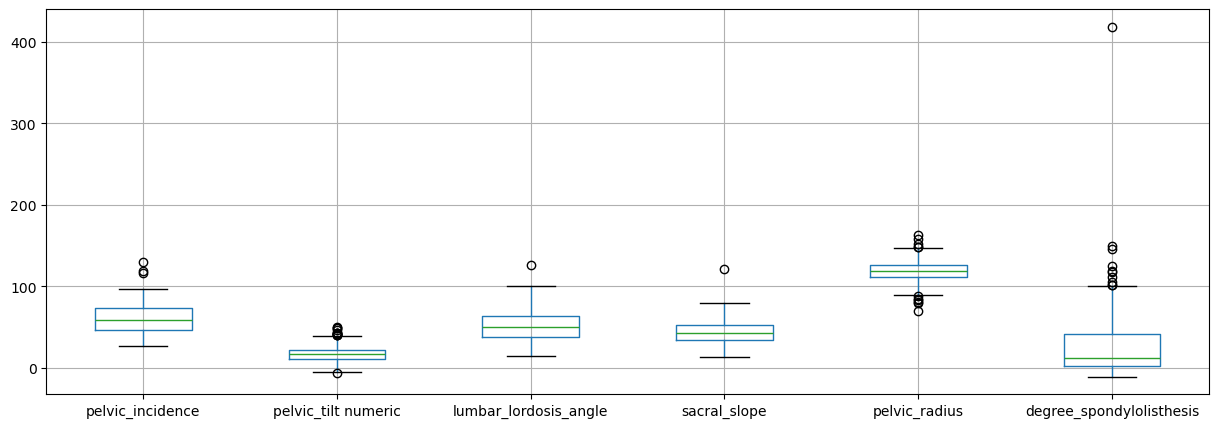

In [99]:
plt.figure(figsize=(15,5))
df.boxplot()
plt.show()

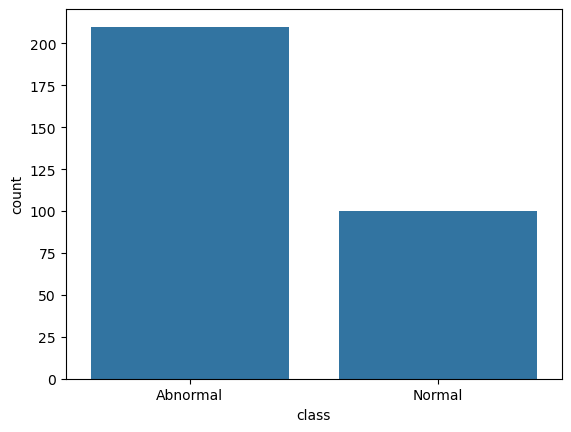

In [100]:
sns.countplot(x=df['class'])
plt.show()

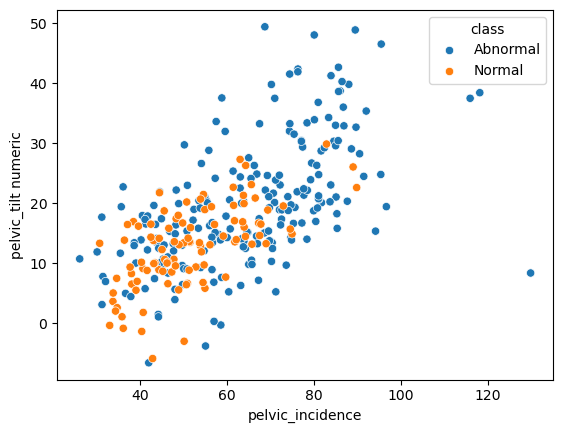

In [101]:
sns.scatterplot(x=df['pelvic_incidence'],y=df['pelvic_tilt numeric'],hue=df['class'])
plt.show()

In [102]:
# 3D
pe.scatter_3d(data_frame=df,x='pelvic_radius',y='pelvic_incidence',z='pelvic_tilt numeric',color='class')

# Encoding

In [103]:
le=LabelEncoder()
df['class']=le.fit_transform(df['class'])

In [104]:
df.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0


# Defining X and y


In [105]:
X=df.drop(columns='class')
y=df['class']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Feature Selection

In [106]:
dtr=DecisionTreeClassifier(random_state=42)
dtr.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [107]:
dtr_cols=pd.Series(
    index=X.columns,
    data=dtr.feature_importances_
)
dtr_imp_cols=dtr_cols.sort_values(ascending=False).head(4).index
dtr_imp_cols

Index(['degree_spondylolisthesis', 'pelvic_radius', 'sacral_slope',
       'pelvic_tilt numeric'],
      dtype='object')

# Scaling

In [108]:
si=StandardScaler()
x_train_scaled=si.fit_transform(x_train[dtr_imp_cols]) 
x_test_scaled=si.transform(x_test[dtr_imp_cols])

# Sampling

In [109]:
df['class'].value_counts()

class
0    210
1    100
Name: count, dtype: int64

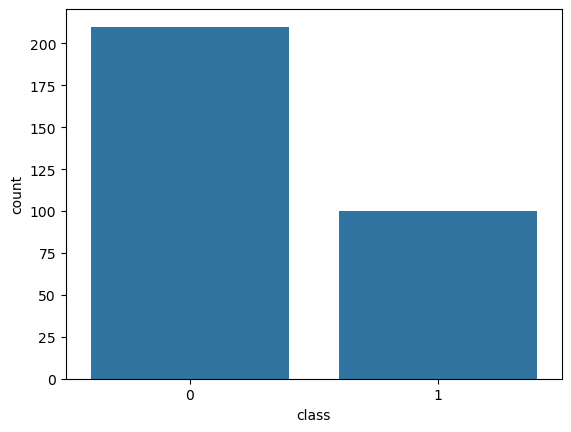

In [110]:
sns.countplot(x=y)
plt.show(
)

In [111]:
ad=ADASYN()
x_ada,y_ada=ad.fit_resample(x_train_scaled,y_train)

In [112]:
y_ada.value_counts()

class
0    166
1    166
Name: count, dtype: int64

# Model Building

In [113]:
sv=SVC()
sv.fit(x_ada,y_ada)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Prediction

In [ ]:
y_pred=svc.predict(x_test_scaled)
y_pred

# Evaluation

In [114]:
print(classification_report(y_test,sv.predict(x_test_scaled)))
print(f'Training Accuracy: {sv.score(x_ada,y_ada)}')
print(f'Testing Accuracy: {sv.score(x_test_scaled,y_test)}')

              precision    recall  f1-score   support

           0       0.97      0.80      0.88        44
           1       0.65      0.94      0.77        18

    accuracy                           0.84        62
   macro avg       0.81      0.87      0.82        62
weighted avg       0.88      0.84      0.85        62

Training Accuracy: 0.8644578313253012
Testing Accuracy: 0.8387096774193549


# Hyperparameter Tuning

In [115]:
params={
    'kernel':['linear','poly','rbf','sigmoid'],
    'C':[0.1,1,10,100],
    'gamma':['scale','auto']
}
Grid=GridSearchCV(SVC(),params,scoring='accuracy',verbose=1)
Grid.fit(x_ada,y_ada)

print(Grid.best_params_)
print(Grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
0.8673450927182271


In [117]:
scv=SVC(C=100, gamma='scale', kernel='rbf')
scv.fit(x_ada,y_ada)

print(confusion_matrix(y_test,scv.predict(x_test_scaled)))
print(classification_report(y_test,scv.predict(x_test_scaled)))
print(f'Training Accuracy: {scv.score(x_ada,y_ada)}')
print(f'Testing Accuracy: {scv.score(x_test_scaled,y_test)}')

[[35  9]
 [ 3 15]]
              precision    recall  f1-score   support

           0       0.92      0.80      0.85        44
           1       0.62      0.83      0.71        18

    accuracy                           0.81        62
   macro avg       0.77      0.81      0.78        62
weighted avg       0.84      0.81      0.81        62

Training Accuracy: 0.9126506024096386
Testing Accuracy: 0.8064516129032258


# Conclusion

This project successfully developed a Support Vector Machine (SVM) model to classify vertebral column conditions as Normal or Abnormal using biomechanical measurements of the spine. The dataset was preprocessed through data cleaning, feature scaling, and train-test splitting to improve model performance. Hyperparameter tuning was also performed to optimize the SVM classifier.

The model achieved a training accuracy of 91.27% and a testing accuracy of 80.65%, indicating that it generalizes well to unseen data with only a moderate difference between training and testing performance. The classification report shows that the model achieved high precision and recall for both classes, with particularly strong performance in identifying abnormal vertebral conditions. The confusion matrix also demonstrates that most samples were classified correctly, with only a few misclassifications.

Overall, the SVM model provides reliable performance for vertebral column classification and can serve as a valuable decision-support tool for the early detection of spinal abnormalities. Future work may include testing additional machine learning algorithms such as Random Forest, XGBoost, or LightGBM, performing feature engineering, and using larger datasets to further improve classification accuracy and model robustness.